In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as pyo
import os


df = pd.read_csv('gdp.csv')
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [60]:
df.isna().sum()

Country Name    0
Country Code    0
Year            0
Value           0
dtype: int64

## 1) How many unique Countries Data we're having in the dataset?

In [61]:
df['Country Name'].nunique() # we are having data of 256 countries

256

## 2) How many years of Data we're having for India

In [62]:
df[df['Country Name'] == 'India']['Year'].count() # we are having 57 years of data for india from 1960 to 2016

57

## 3) Whats the world GDP in 1969?

In [63]:
df[(df['Country Name']=='World')&(df['Year']==1969)]['Value'].values[0] # world gdp in 1969 - 2,690,797,713,906.75

2690797713906.75

## 4) Whats the % of GDP growth of India in Year 1994 (*as compare to 1993)?

In [64]:
df[(df['Country Name']=='India')&(df['Year'].isin([1993,1994]))] ## to find value wise
df[(df['Country Name']=='India')&(df['Year'].between(1990,2000))] ## to slice value wise 
## percent calculation
gdp_1993 = df[(df['Country Name']=='India')&(df['Year'].isin([1993]))]['Value'].values[0]
gdp_1994 = df[(df['Country Name']=='India')&(df['Year'].isin([1994]))]['Value'].values[0]

percent = ((gdp_1994-gdp_1993)/gdp_1993)*100
percent 
### therefore 17% of gdp growth 


17.178748210146075

# Tasks

### 1) Find GDP Growth of India from 1960 - 2016
### 2) Create a new columns named as GDP which shows the GDP growth of each country for that year
### 3) Create a graph of GDP Growth of India from 1960 - 2016

##### Task 1

In [65]:
India_gdp = df[df['Country Name']=='India']
gdp_1960 = India_gdp[India_gdp['Year']==1960]['Value'].values[0]
gdp_2016 = India_gdp[India_gdp['Year']==2016]['Value'].values[0]

growth = ((gdp_2016-gdp_1960)/gdp_1960)*100
growth


6096.072762594173

#### Task 2

In [66]:
# lst = []
# prev_years = {}

# def gdpFinder( value , prev_val):
#     return ((value-prev_val)/prev_val)*100

# for i in range(len(df)):
#     year = df['Year'][i]
#     country = df['Country Name'][i]
#     c_val = df['Value'][i]
#     if year<=df[df['Country Name']==country]['Year'].min():
#         lst.append(0)
#         prev_years[country] = year
#     else:
#         p_val = df[(df['Country Name']==country)&(df['Year']==prev_years[country])]['Value'].values[0]
#         prev_years[country] = year
#         lst.append(gdpFinder(c_val,p_val))

# df['GDP_Growth(%)'] = lst

In [67]:
## easy fast approach 
df = df.sort_values(['Country Name' , 'Year'])
df['GDP_Growth(%)']=df.groupby(by="Country Name")['Value'].pct_change()*100

In [68]:
df[df['Country Name']=='India']['GDP_Growth(%)'].mean() ## from 1960 to 2016 India shown 8% of annual growth in gdp

8.010818928223234

In [69]:
df.sort_index(inplace=True)
df

,Country Name,Country Code,Year,Value,GDP_Growth(%)
0,Arab World,ARB,1968,2.576068e+10,NaN
1,Arab World,ARB,1969,2.843420e+10,10.378298
2,Arab World,ARB,1970,3.138550e+10,10.379387
3,Arab World,ARB,1971,3.642691e+10,16.062864
4,Arab World,ARB,1972,4.331606e+10,18.912246
...,...,...,...,...,...
11502,Zimbabwe,ZWE,2012,1.424249e+10,17.721604
11503,Zimbabwe,ZWE,2013,1.545177e+10,8.490639
11504,Zimbabwe,ZWE,2014,1.589105e+10,2.842915
11505,Zimbabwe,ZWE,2015,1.630467e+10,2.602840


In [70]:
df_grow = df.groupby('Country Name')['GDP_Growth(%)'].mean()

In [71]:
df_grow = pd.DataFrame(df_grow)

In [72]:
df_grow.nlargest(10 , columns='GDP_Growth(%)')

,GDP_Growth(%)
Country Name,
Cayman Islands,216.761448
Nauru,22.947011
Equatorial Guinea,22.741644
Iraq,18.528494
Oman,18.028124
Qatar,17.732720
Switzerland,16.452862
Cambodia,15.296994
Myanmar,15.097340


<Axes: xlabel='Country Name'>

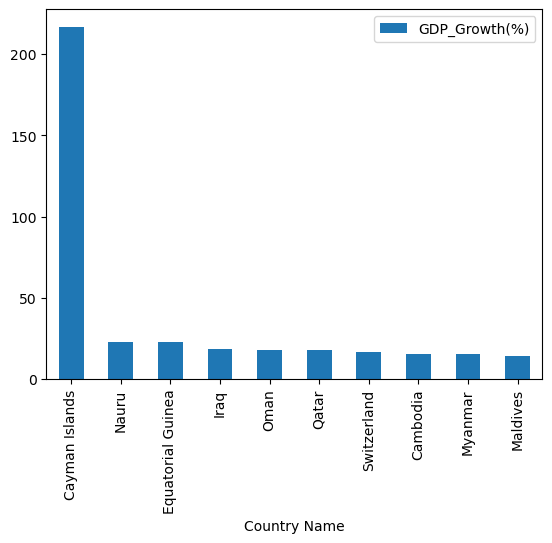

In [73]:
df_grow.sort_values(by='GDP_Growth(%)' , ascending=False).head(10).plot(kind='bar')

##### -> graph above shows top 10 fastest growing economies

#### Task 3

In [74]:
df_grow.reset_index(inplace=True)

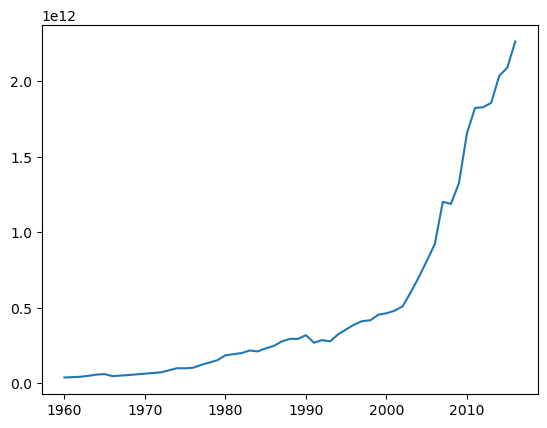

In [75]:
plt.plot(df[df['Country Name']=='India']['Year'] ,df[df['Country Name']=='India']['Value'] )

<Axes: xlabel='Year'>

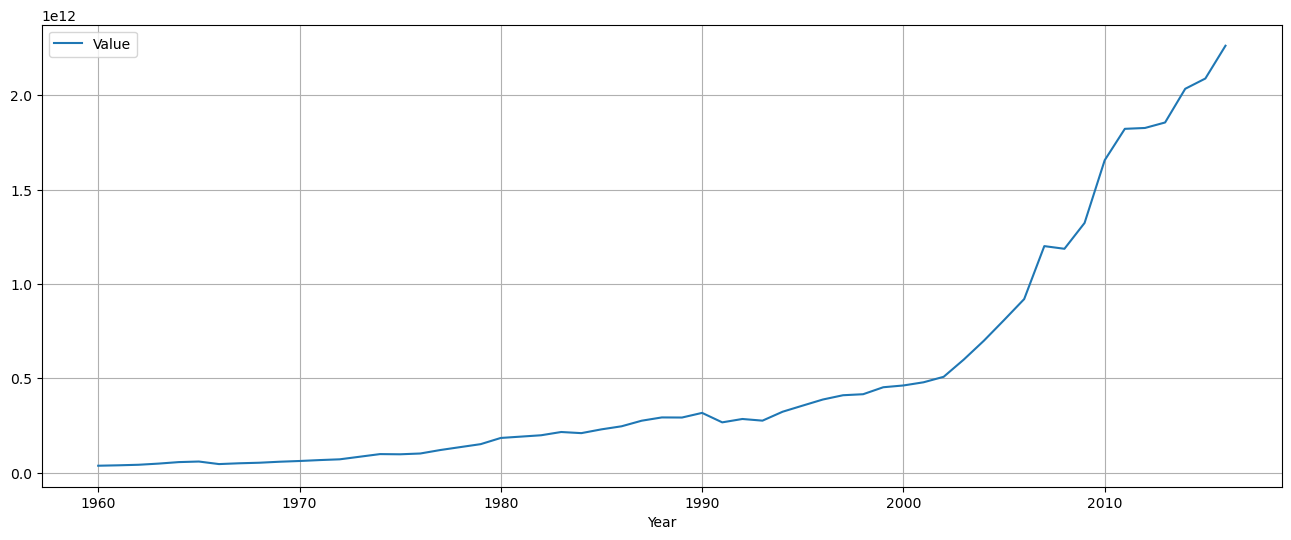

In [76]:
df[df['Country Name']=='India'].plot(kind='line' , x='Year' , y='Value' , grid=True , figsize=(16,6))

## Interactive Graphs

In [ ]:
fig = px.line(data_frame=df[df['Country Name']=='India'] , x='Year' , y='Value' , title='India GDP Ananlysis' )
fig

In [ ]:
pyo.plot(fig , filename='India GDP Ananlysis.html' , auto_open=False)

'India GDP Ananlysis.html'

In [79]:
fig1 = px.line(data_frame=df[df['Country Name']=='World'] , x='Year' , y='Value' , title='World GDP Ananlysis')
fig1

In [ ]:
pyo.plot(fig1 , filename='World GDP Ananlysis.html' , auto_open=False)

'World GDP Ananlysis.html'

#### Bulk graph creation

In [81]:
os.mkdir('GDP_Graphs')

In [ ]:
# for country_name in df['Country Name'].unique():
#     df_pr = df[df['Country Name']==country_name]
#     fig = px.line(data_frame=df_pr , x='Year' , y='Value' , title=country_name+' GDP Analysis')
#     pyo.plot(fig , filename="GDP_Graphs/"+country_name+'.html' , auto_open=False)


### Function to create graph of any Two countries 

In [94]:
def graphMaker(country1 , country2):
    df_pro = df[(df['Country Name']==country1) | (df['Country Name']==country2)]
    fig = px.line( df_pro, x='Year' , y='Value' , title=country1+' | '+country2 , color=df_pro['Country Name'])
    pyo.plot(fig , filename= country1+'_'+country2 +'.html')


In [95]:
graphMaker('India' , 'China')

### Comparision of every country on df

In [97]:
fig = px.line(df , x='Year'  , y='Value' , title="Whole GDP Analysis" , color=df['Country Name'])
pyo.plot(fig , filename='WholeGDP.html')

'WholeGDP.html'

### Graph of multiple countries 

In [108]:
lst = ['India' , 'China' , 'Italy']



def Graphs(lst):
    dfs = []
    for i in lst:
        dfs.append(df[df['Country Name'] == i])
    df_new = pd.concat(dfs , axis=0)

    fig = px.line(df_new , x='Year' , y='Value' , title='-'.join(lst)+' GDP Analysis' , color=df_new['Country Name'])
    pyo.plot(fig , filename='-'.join(lst)+'.html' , auto_open=False)

Graphs(lst)

### GDP Growth Analysis

In [109]:
fig = px.line(df, x = 'Year', y = 'GDP_Growth(%)', title = 'GDP Growth Comparison', color = 'Country Name')
pyo.plot(fig, filename = 'GDP Growth.html', auto_open = True)

'GDP Growth.html'

In the above graph there lies outliers because of missing data 

## GDP Growth Analysis from 1960 - 2016

In [111]:
dfs = []

for country_name in df['Country Name'].unique():
    df_pr = df[df['Country Name'] == country_name]
    
    if (len(df_pr) == 57):
        dfs.append(df_pr)
        
df_pr = pd.concat(dfs, axis = 0)

fig = px.line(df_pr, x = 'Year', y = 'GDP_Growth(%)', title = 'GDP Growth', color = 'Country Name')

pyo.plot(fig, filename = 'GDP Growth 1960-2016.html', auto_open = True)

'GDP Growth 1960-2016.html'